# Analyze the oracle and selector sweep

Read `oracle_reference.csv` and `selector_results.csv` from this directory with NumPy, pandas and Matplotlib. This report uses only saved masks and measurements. The reference hash prevents joining a sweep to a different oracle.

For nonnegative row importance $v_i$ and a mask $M$, define $I(M)=\sum_i v_iM_i$ and $L(M)=\sum_C T(|C|)$ over maximal selected runs. At requested count $R$, the oracle bounds $\eta_R^\star=\max_{|M|=R}I(M)/L(M)$ between $\ell$ and $u$. The saved gap interval is

$$\max(0,100(1-(I/L)/\ell))\le g(M)\le\max(0,100(1-(I/L)/u)).$$

Only exact-fill masks with positive total importance have a fixed-$R$ gap. Paper may underfill; those masks retain their other measurements. Retained importance is $100I/\sum_i v_i$, an activation-based proxy.

Tile widths follow $B_j=\max(1,\lceil s/2^j\rceil)$ down to `Top-R` at one row, alongside the coarse $1s$–$2s$ branch. Here $s$ is the fitted boundary in rows. Widths are deduplicated separately for each shape, so the report uses the recorded method lists.

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

REFERENCE = Path("oracle_reference.csv")
RESULTS = Path("selector_results.csv")

In [2]:
reference = pd.read_csv(REFERENCE)
selectors = pd.read_csv(RESULTS)
assert not reference.empty and not selectors.empty
assert selectors.reference_sha256.eq(hashlib.sha256(REFERENCE.read_bytes()).hexdigest()).all()
keys = ["trace_id", "shape", "fraction", "N", "R_nominal"]
assert not reference.duplicated(keys).any() and not selectors.duplicated(keys+["method"]).any()
matched = selectors[keys].merge(reference[keys], on=keys, how="outer", indicator=True)
assert matched._merge.eq("both").all(), "Reference and selector cases differ."
expected = selectors.groupby("shape").method.agg(frozenset)
for key, methods in selectors.groupby(keys).method.agg(frozenset).items():
    assert methods == expected.loc[key[1]], "Missing selector methods at some cases."
oracle = reference.rename(columns={"oracle_importance": "importance",
    "oracle_latency": "latency", "oracle_intervals": "intervals"}).assign(method="Global DP")
results = pd.concat([oracle, selectors], ignore_index=True)

In [3]:
tile_methods = selectors.loc[selectors.tile_width.notna(), "method"].drop_duplicates().tolist()
method_order = ["Global DP", "Paper greedy", *tile_methods]
results["method"] = pd.Categorical(results.method, categories=method_order, ordered=True)
results = results.sort_values(["trace_id", "fraction", "method"])
method_colors = {"Global DP": "black", "Paper greedy": "tab:orange"}
method_colors.update(zip(tile_methods, plt.cm.viridis(np.linspace(.1, .9, len(tile_methods)))))
method_colors["Top-R"] = "tab:red"
results.head()

,trace_id,shape,prompt,fraction,N,R_nominal,saturation_rows,eta_lower,eta_upper,oracle_calls,...,short_chunks,shortfall_rows,overhead_ms,gap_lower_pct,gap_upper_pct,intervals,method,tile_scale,tile_width,reference_sha256
0,0,896x896,0,0.1,896,89,117.714286,3785.438363,3785.441802,21.0,...,1,28.714286,0.002891,0.000000e+00,0.000091,"[[483, 572]]",Global DP,NaN,NaN,NaN
1152,0,896x896,0,0.1,896,89,117.714286,NaN,NaN,NaN,...,1,29.714286,0.002992,NaN,NaN,"[[480, 568]]",Paper greedy,NaN,NaN,e535b6b0af60b83ab9dc412274f5313c82f99bff17cf65...
1153,0,896x896,0,0.1,896,89,117.714286,NaN,NaN,NaN,...,1,28.714286,0.002891,1.110223e-14,0.000091,"[[483, 572]]",Tiles (1s),1.00,118.0,e535b6b0af60b83ab9dc412274f5313c82f99bff17cf65...
1154,0,896x896,0,0.1,896,89,117.714286,NaN,NaN,NaN,...,1,28.714286,0.002891,1.110223e-14,0.000091,"[[483, 572]]",Tiles (1.25s),1.25,148.0,e535b6b0af60b83ab9dc412274f5313c82f99bff17cf65...
1155,0,896x896,0,0.1,896,89,117.714286,NaN,NaN,NaN,...,1,28.714286,0.002891,1.110223e-14,0.000091,"[[483, 572]]",Tiles (1.5s),1.50,177.0,e535b6b0af60b83ab9dc412274f5313c82f99bff17cf65...


## 1. Compare ratio gaps and fragmentation

In [4]:
frame = results[results.status == "ok"]
eligible = frame[(frame.R_selected == frame.R_nominal) & frame.gap_upper_pct.notna()]

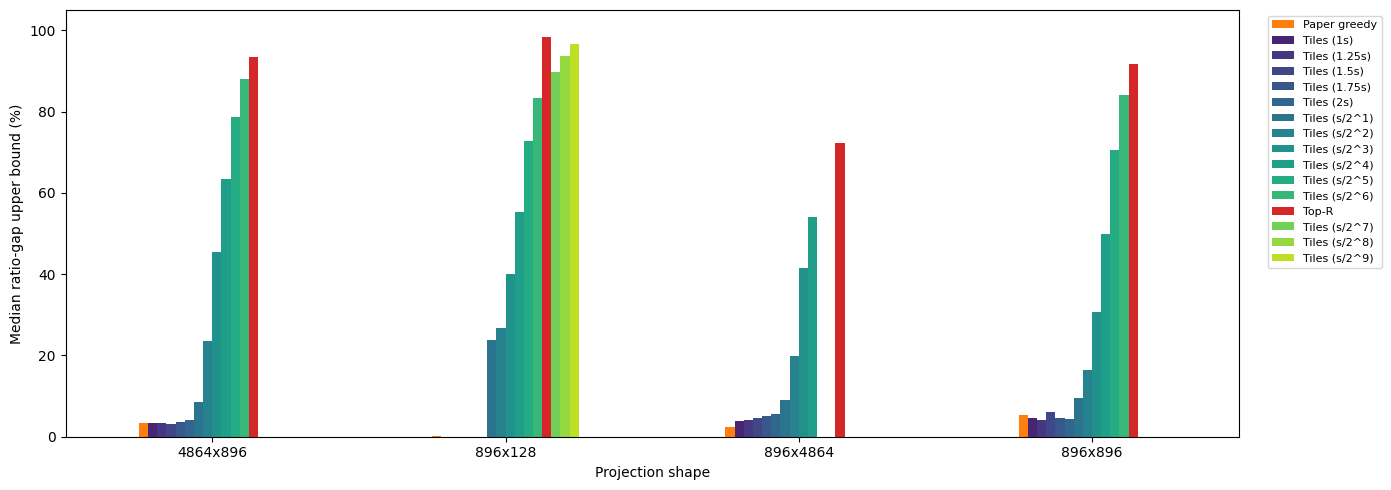

In [5]:
gaps = eligible[eligible.method != "Global DP"].groupby(
    ["shape", "method"], observed=True).gap_upper_pct.median().unstack()
ax = gaps.reindex(columns=method_order[1:]).plot.bar(
    figsize=(14, 5), rot=0, color=[method_colors[name] for name in method_order[1:]])
ax.set(xlabel="Projection shape", ylabel="Median ratio-gap upper bound (%)", ylim=(0, 105))
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Figure 1.** Median ratio-gap upper bounds by shape. The table gives case counts, minimum fill percentage, median gap, run count and short-run overhead. Paper's gap uses only exact-fill cases with a defined ratio, so its bars and the other methods' bars may describe different subsets. Missing gaps have no eligible cases.

The short-run deficit is $D(M)=\sum_C(s-|C|)_+$, where $s$ is the fitted boundary in rows. With short and long slopes $b_1,b_2$, the saved overhead is $(b_2-b_1)D(M)$ and total cost is $L=b_2|M|+(b_2-b_1)D(M)$.

In [6]:
summary = results.groupby(["shape", "method"], observed=True).agg(
    cases=("method", "size"), gap_cases=("gap_upper_pct", "count"),
    min_fill_pct=("fill_pct", "min"), median_gap_pct=("gap_upper_pct", "median"),
    median_runs=("chunks", "median"), median_overhead_ms=("overhead_ms", "median"))
summary.round(3)

cases  gap_cases  min_fill_pct  median_gap_pct  \
shape    method                                                          
4864x896 Global DP        288        288       100.000           0.000   
         Paper greedy     288         64        99.918           3.397   
         Tiles (1s)       288        288       100.000           3.304   
         Tiles (1.25s)    288        288       100.000           3.268   
         Tiles (1.5s)     288        288       100.000           3.196   
         Tiles (1.75s)    288        288       100.000           3.697   
         Tiles (2s)       288        288       100.000           4.128   
         Tiles (s/2^1)    288        288       100.000           8.540   
         Tiles (s/2^2)    288        288       100.000          23.492   
         Tiles (s/2^3)    288        288       100.000          45.399   
         Tiles (s/2^4)    288        288       100.000          63.436   
         Tiles (s/2^5)    288        288       100.000          78.773   
         Tiles (s/2^6)    288        288       100.000          88.084   
         Top-R            288        288       100.000          93.537   
896x128  Global DP        288        288       100.000           0.000   
         Paper greedy     288         32        71.910           0.227   
         Tiles (1s)       288        288       100.000           0.000   
         Tiles (1.25s)    288        288       100.000           0.000   
         Tiles (1.5s)     288        288       100.000           0.000   
         Tiles (1.75s)    288        288       100.000           0.000   
         Tiles (2s)       288        288       100.000           0.000   
         Tiles (s/2^1)    288        288       100.000          23.750   
         Tiles (s/2^2)    288        288       100.000          26.836   
         Tiles (s/2^3)    288        288       100.000          40.018   
         Tiles (s/2^4)    288        288       100.000          55.291   
         Tiles (s/2^5)    288        288       100.000          72.666   
         Tiles (s/2^6)    288        288       100.000          83.309   
         Top-R            288        288       100.000          98.272   
         Tiles (s/2^7)    288        288       100.000          89.715   
         Tiles (s/2^8)    288        288       100.000          93.595   
         Tiles (s/2^9)    288        288       100.000          96.651   
896x4864 Global DP        288        288       100.000           0.000   
         Paper greedy     288        288       100.000           2.377   
         Tiles (1s)       288        288       100.000           3.884   
         Tiles (1.25s)    288        288       100.000           4.202   
         Tiles (1.5s)     288        288       100.000           4.560   
         Tiles (1.75s)    288        288       100.000           5.209   
         Tiles (2s)       288        288       100.000           5.665   
         Tiles (s/2^1)    288        288       100.000           8.979   
         Tiles (s/2^2)    288        288       100.000          19.836   
         Tiles (s/2^3)    288        288       100.000          41.586   
         Tiles (s/2^4)    288        288       100.000          54.159   
         Top-R            288        288       100.000          72.156   
896x896  Global DP        288        288       100.000           0.000   
         Paper greedy     288         96        98.324           5.363   
         Tiles (1s)       288        288       100.000           4.694   
         Tiles (1.25s)    288        288       100.000           4.086   
         Tiles (1.5s)     288        288       100.000           6.015   
         Tiles (1.75s)    288        288       100.000           4.569   
         Tiles (2s)       288        288       100.000           4.422   
         Tiles (s/2^1)    288        288       100.000           9.484   
         Tiles (s/2^2)    288        288       100.000          16.488   
         Tiles (s/2^3)    28

## 2. Inspect importance–latency trajectories

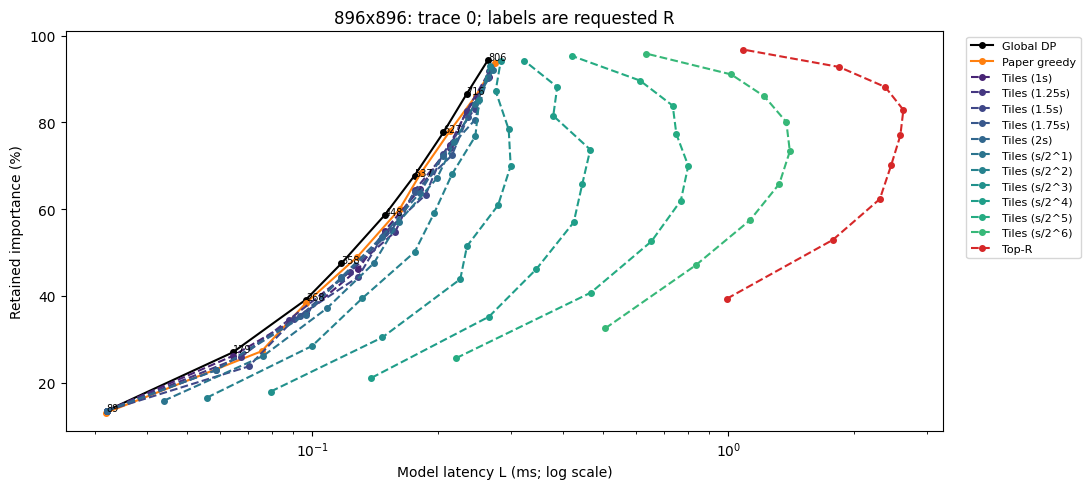

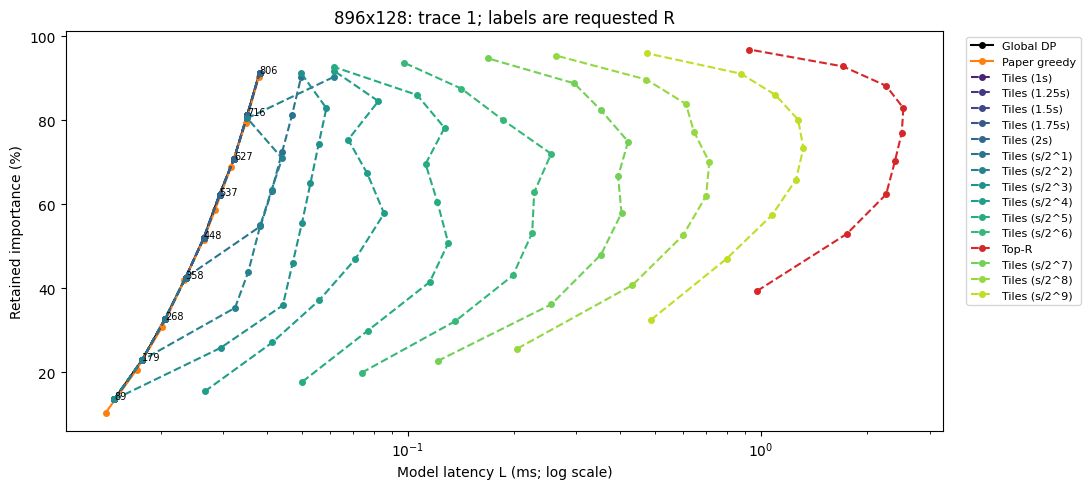

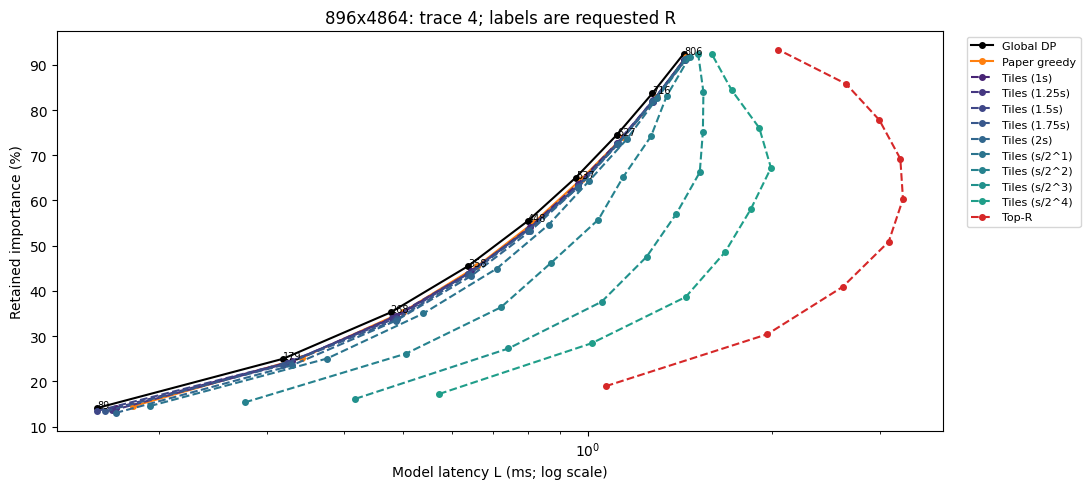

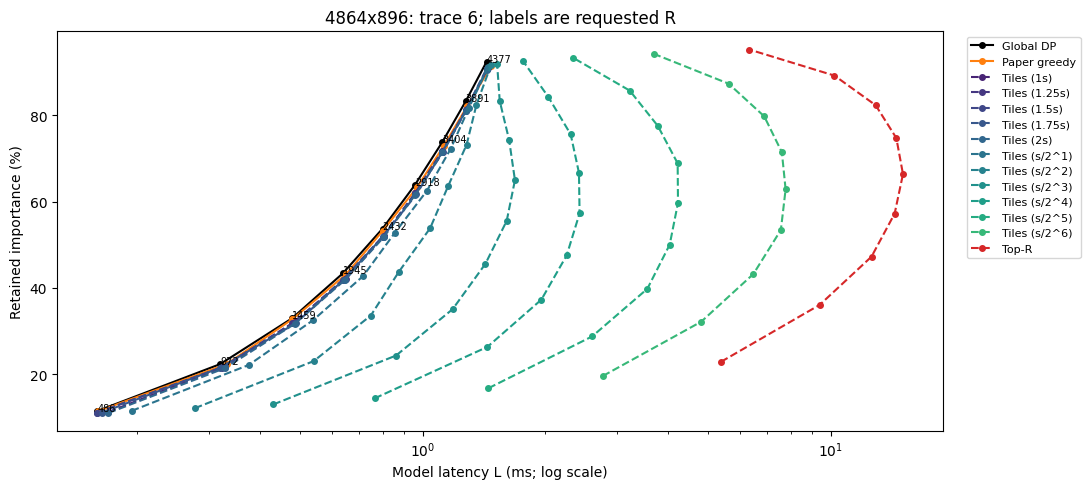

In [7]:
for shape, data in frame.groupby("shape", sort=False):
    points = data[data.trace_id == data.trace_id.min()]
    plt.figure(figsize=(11, 5))
    for name, group in points.groupby("method", sort=False, observed=True):
        group = group.sort_values("fraction")
        plt.plot(group.latency, group.retained_pct, "o", label=name, ms=4,
                 color=method_colors[name], linestyle="--" if name in tile_methods else "-")
        if name == "Global DP":
            for row in group.itertuples():
                plt.annotate(str(row.R_nominal), (row.latency, row.retained_pct), fontsize=7)
    plt.xscale("log")
    plt.xlabel("Model latency L (ms; log scale)")
    plt.ylabel("Retained importance (%)")
    plt.title(f"{shape}: trace {points.trace_id.iloc[0]}; labels are requested R")
    plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

**Figure 2.** Importance–latency trajectories for the first available trace of each shape. Points are masks; lines connect requested budgets, and oracle labels give $R$. Paper may underfill. Latency can decrease as intervals merge and their short-run penalty falls. Empty and zero-importance cases are omitted. Fixed-$R$ ratio optima need not form the complete Pareto frontier.

## 3. Inspect selected runs

In [8]:
def saved_mask(row):
    mask = np.zeros(int(row.N), bool)
    for start, end in json.loads(row.intervals):
        mask[start:end] = True
    return mask


first = results[results.trace_id == results.trace_id.min()]
fraction = first.fraction.iloc[(first.fraction - .5).abs().argmin()]
example = first[np.isclose(first.fraction, fraction)].set_index("method")
methods = {name: saved_mask(row) for name, row in example.iterrows()}

In [9]:
example[["R_nominal", "R_selected", "importance", "latency",
         "chunks", "gap_upper_pct"]].round(3)

,R_nominal,R_selected,importance,latency,chunks,gap_upper_pct
method,,,,,,
Global DP,448,448,525.575,0.149,4,0.000
Paper greedy,448,448,537.603,0.162,5,5.762
Tiles (1s),448,448,492.726,0.149,4,6.223
Tiles (1.25s),448,448,491.212,0.158,4,11.861
Tiles (1.5s),448,448,488.945,0.149,2,6.943
Tiles (1.75s),448,448,493.736,0.155,2,9.568
Tiles (2s),448,448,480.367,0.147,2,7.089
Tiles (s/2^1),448,448,511.028,0.161,5,9.893
Tiles (s/2^2),448,448,530.751,0.197,8,23.297


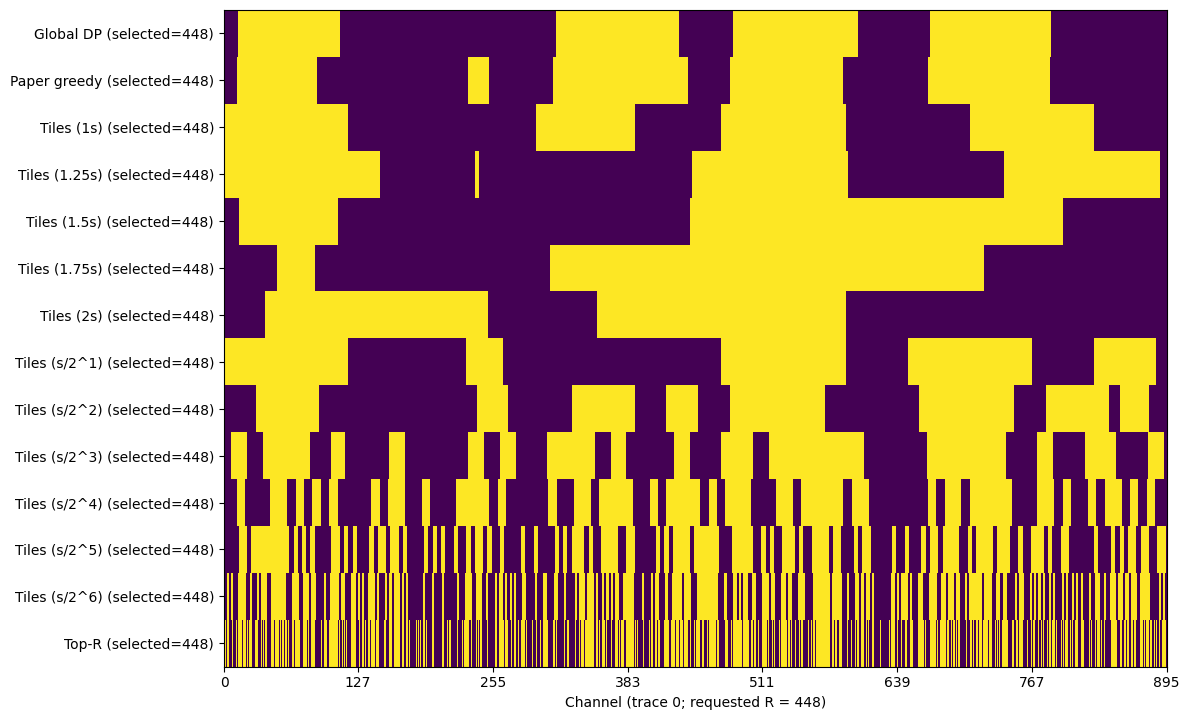

In [10]:
N, R = int(example.N.iloc[0]), int(example.R_nominal.iloc[0])
plt.figure(figsize=(12, max(2.4, 0.45 * len(methods) + 1)))
plt.imshow(np.array(list(methods.values())), aspect="auto", interpolation="nearest")
plt.yticks(range(len(methods)), [f"{name} (selected={mask.sum()})" for name, mask in methods.items()])
plt.xticks(np.linspace(0, N - 1, 8, dtype=int))
plt.xlabel(f"Channel (trace {int(example.trace_id.iloc[0])}; requested R = {R})")
plt.tight_layout()
plt.show()

**Figure 3.** Bright cells are selected channels. The example uses the first available trace and its available budget closest to one half. The table gives importance and cost; the image shows how selection is distributed across runs. Short runs incur the deficit penalty above, but a valuable short run can still improve the ratio.

## 4. Summarize the comparison

The tables below summarize gaps over all eligible cases and then compare Paper and the recorded tile widths within each shape on the same cases, matched by trace, shape and requested budget. Medians weight each case equally. A missing median means that no eligible cases exist.

In [11]:
tables = []
for shape, data in eligible.groupby("shape", observed=True):
    names = results.loc[results["shape"] == shape, "method"].drop_duplicates().tolist()
    gaps = data.pivot(index=["trace_id", "R_nominal", "fraction"],
                      columns="method", values="gap_upper_pct").reindex(columns=names)
    paired = gaps.drop(columns="Global DP").dropna()
    table = pd.concat({"All eligible": gaps.agg(["median", "count"]).T,
                       "Matched Paper / tiles": paired.agg(["median", "count"]).T})
    tables.append(pd.concat({shape: table}, names=["Shape", "Comparison", "Method"]))
display(pd.concat(tables).rename(columns={"median": "Gap upper bound (%)", "count": "Cases"}).round(3))

Gap upper bound (%)  Cases
Shape    Comparison            Method                                   
4864x896 All eligible          Global DP                    0.000  288.0
                               Paper greedy                 3.397   64.0
                               Tiles (1s)                   3.304  288.0
                               Tiles (1.25s)                3.268  288.0
                               Tiles (1.5s)                 3.196  288.0
...                                                           ...    ...
896x896  Matched Paper / tiles Tiles (s/2^3)               29.439   96.0
                               Tiles (s/2^4)               48.339   96.0
                               Tiles (s/2^5)               68.722   96.0
                               Tiles (s/2^6)               83.723   96.0
                               Top-R                       91.816   96.0

[110 rows x 2 columns]

The oracle searches the full fixed-$R$ mask space to the specified ratio tolerance. Its gaps quantify how much ratio each heuristic leaves under the fitted cost. The decomposition $L=b_2|M|+(b_2-b_1)D(M)$ connects that comparison to run geometry: at equal row count, differences in modeled latency come entirely from short-run deficit.

The conclusions concern activation-magnitude importance and an additive latency model. They do not establish end-to-end accuracy or measured SSD speedup; native task splitting and scheduling are outside this model.

## Granularity and fragmentation

Within each shape, aggregate the same trace/budget cases at each realized tile width. The geometric branch reaches one row; the coarse branch tests widths above the reference. Plot width on a base-two logarithmic axis so each halving has equal spacing. Smaller widths need not produce monotone gaps or run counts.

An abrupt change in these curves identifies a transition to investigate on the recorded workloads. It does not by itself establish a universal minimum useful width.

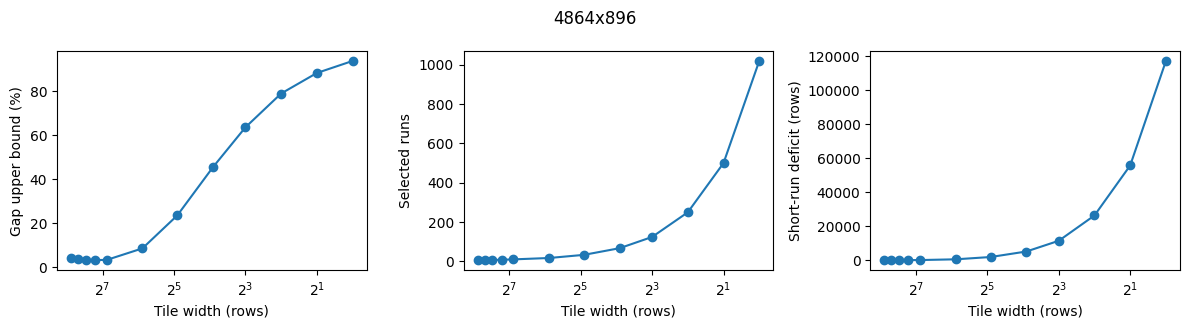

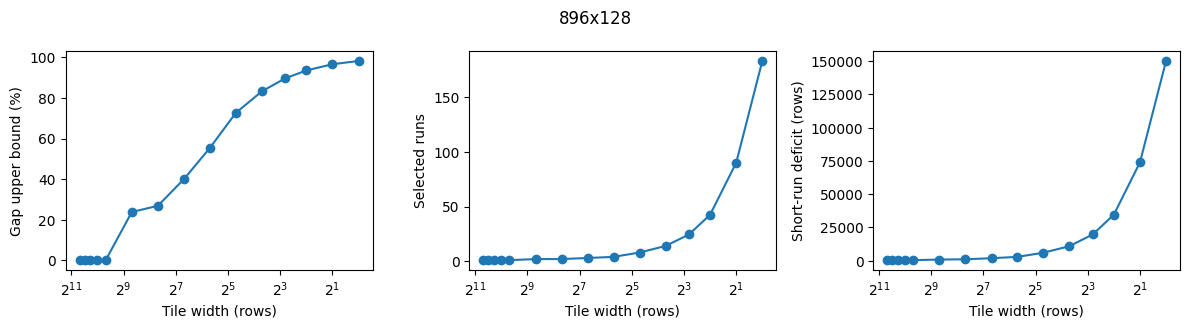

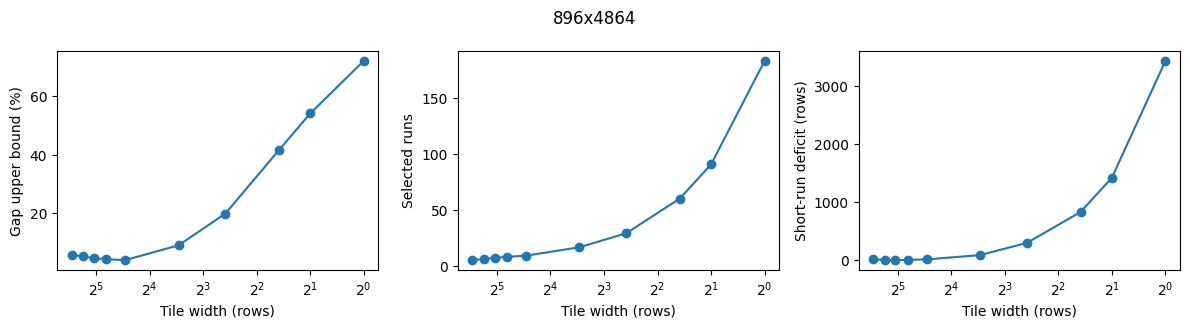

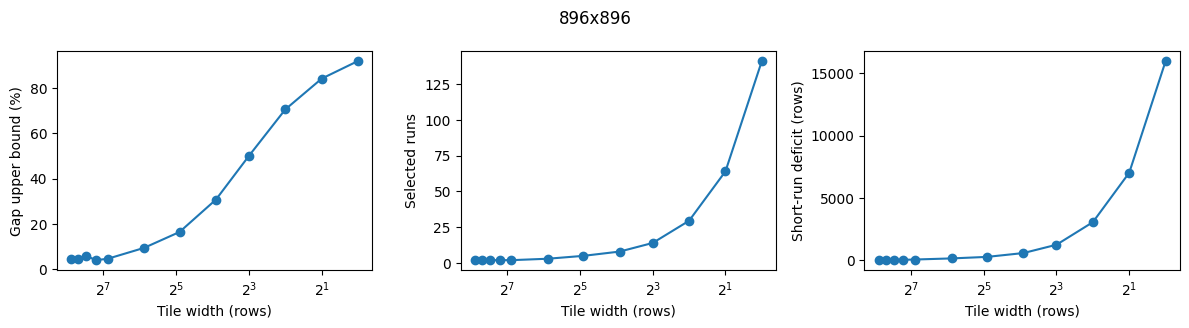

In [12]:
granularity = eligible[eligible.tile_width.notna()].groupby(
    ["shape", "tile_width"], observed=True).agg(
    gap=("gap_upper_pct", "median"), runs=("chunks", "median"),
    shortfall=("shortfall_rows", "median"), cases=("trace_id", "size")).reset_index()
for shape, data in granularity.groupby("shape"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
    for ax, metric, label in zip(axes, ["gap", "runs", "shortfall"],
            ["Gap upper bound (%)", "Selected runs", "Short-run deficit (rows)"]):
        ax.plot(data.tile_width, data[metric], "o-")
        ax.set(xscale="log", xlabel="Tile width (rows)", ylabel=label)
        ax.set_xscale("log", base=2)
        ax.invert_xaxis()
    fig.suptitle(shape)
    fig.tight_layout()
    plt.show()

The text below reports the observed endpoint and all widths tied for the smallest median gap. Rankings and values are recomputed from the saved sweep.

In [13]:
findings = []
for shape, data in granularity.groupby("shape"):
    endpoint = data[data.tile_width == 1]
    best = data[data.gap == data.gap.min()]
    widths = ", ".join(str(int(b)) for b in best.tile_width)
    end = f"{endpoint.gap.iloc[0]:.3f}%" if len(endpoint) else "undefined"
    findings.append(f"- **{shape}**: lowest median gap **{best.gap.min():.3f}%** "
                    f"at **{widths} rows**; the one-row Top-R endpoint is **{end}**.")
display(Markdown("\n".join(findings)))

- **4864x896**: lowest median gap **3.196%** at **177 rows**; the one-row Top-R endpoint is **93.537%**.
- **896x128**: lowest median gap **0.000%** at **824, 1030, 1236, 1442, 1648 rows**; the one-row Top-R endpoint is **98.272%**.
- **896x4864**: lowest median gap **3.884%** at **22 rows**; the one-row Top-R endpoint is **72.156%**.
- **896x896**: lowest median gap **4.086%** at **148 rows**; the one-row Top-R endpoint is **91.791%**.